# 23CSE301 Machine Learning — Capstone Project
## Regression Track — Review 1

**Team:** TASKMASTERS (Team 16)  
**Dataset:** Statistics of PGA Tournaments During the 2022 Season  
**Target:** `avgScore`

---

### Project objective

This notebook develops regression models to estimate a golfer's scoring average from driving and putting performance statistics. The analysis follows a consistent modelling pipeline so that all ten required algorithms are evaluated on the same train/test split.

### Review 1 scope

| Component | Coverage |
|---|---|
| Exploratory data analysis | Dataset audit, distributions, target analysis, correlation and feature-target relationships |
| Preprocessing | Missing-value handling, outlier assessment, scaling and reproducible splitting |
| Feature engineering | Combined strokes-gained feature (`totalSG`) |
| Regression models | 10 algorithms required for Review 1 |
| Model selection | Hyperparameter tuning and 5-fold cross-validation |
| Diagnostics | Predicted-vs-actual, residual analysis and tree-based feature importance |

### Notebook structure

**EDA → Data preparation → Feature engineering → Ten regression models → Evaluation → Cross-validation → Diagnostics → Review 1 summary**

The notebook is designed as a technical report: explanatory text states the modelling rationale, while the code cells produce the corresponding evidence and results.


### Regression model reference

All ten algorithms use the same modelling data and held-out test set. Their differences are summarised below.

| # | Algorithm | Core idea |
|---:|---|---|
| 1 | **Linear Regression** | Estimates a linear relationship between predictors and the target. |
| 2 | **Ridge Regression** | Adds L2 regularisation to control coefficient magnitude. |
| 3 | **Lasso Regression** | Uses L1 regularisation and can drive coefficients to zero. |
| 4 | **ElasticNet** | Combines L1 and L2 regularisation through `l1_ratio`. |
| 5 | **Polynomial Regression** | Expands the feature space to represent curved relationships and interactions. |
| 6 | **Decision Tree Regressor** | Learns non-linear decision rules through recursive feature splits. |
| 7 | **Random Forest Regressor** | Averages predictions from multiple decision trees to reduce variance. |
| 8 | **Gradient Boosting Regressor** | Builds trees sequentially to reduce the errors of earlier trees. |
| 9 | **Support Vector Regressor** | Fits a function within an epsilon-insensitive margin; kernels enable non-linear fits. |
| 10 | **K-Nearest Neighbors Regressor** | Predicts from the target values of nearby observations. |

**Key modelling distinction:** scaling is important for coefficient- and distance-based models such as Ridge, Lasso, ElasticNet, SVR and KNN, while tree-based models are insensitive to feature scale.


In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid", palette="colorblind")

# The SCORE page provides PGA2022.csv through the link shown on the dataset page.
DATA_URL = "https://data.scorenetwork.org/data/PGA2022.csv"
DATA_DIR = Path("../data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_PATH = DATA_DIR / "PGA2022.csv"

def load_pga_data():
    # First use the local copy. This makes the notebook stable after the CSV
    # has been downloaded once.
    if LOCAL_PATH.exists():
        return pd.read_csv(LOCAL_PATH, encoding="latin1")

    # If the local file is not present, try the official CSV URL.
    data = pd.read_csv(DATA_URL, encoding="latin1")
    data.to_csv(LOCAL_PATH, index=False)
    return data

df = load_pga_data()

print("Shape:", df.shape)
display(df.head())


Shape: (1387, 13)


,Unnamed: 0,playerName,country,avgDriveDist,drivePct,avgPuttsPerRound,onePuttPct,driveSG,puttsSG,avgScore,Money,Points,tournament
0,1,Luke List,United States,319.5,60.71,28.0,43.06,0.724,-0.529,70.510,79420.0,39.0,The American Express
1,2,Will Zalatoris,United States,317.4,58.93,26.5,47.22,0.787,-0.752,69.435,256500.0,92.0,The American Express
2,3,Joseph Bramlett,United States,315.3,73.21,28.5,43.06,1.554,-0.045,70.173,39683.0,20.0,The American Express
3,4,Wyndham Clark,United States,313.0,62.50,27.0,47.22,0.352,0.500,70.435,161500.0,60.0,The American Express
4,5,Paul Barjon,France,311.1,62.50,28.5,44.44,1.297,0.190,69.935,207100.0,75.0,The American Express


## Section A — Dataset & EDA

### A1. Dataset loading and audit

The rubric asks us to report the dataset shape, data types, missing values, duplicates and target distribution before modelling.

In [2]:
print("Number of rows:", len(df))
print("Number of columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing = df.isna().sum().sort_values(ascending=False)
display(missing.to_frame("missing_count"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget summary — avgScore:")
display(df["avgScore"].describe().to_frame("avgScore"))


Number of rows: 1387
Number of columns: 13

Data types:


,dtype
Unnamed: 0,int64
playerName,str
country,str
avgDriveDist,float64
drivePct,float64
avgPuttsPerRound,float64
onePuttPct,float64
driveSG,float64
puttsSG,float64
avgScore,float64



Missing values:


,missing_count
Points,63
Money,63
avgDriveDist,11
drivePct,11
country,11
puttsSG,11
driveSG,11
avgPuttsPerRound,11
onePuttPct,11
avgScore,11



Duplicate rows: 0

Target summary — avgScore:


,avgScore
count,1376.000000
mean,70.121359
std,1.519537
min,64.966000
25%,69.128000
50%,70.139500
75%,71.154000
max,75.347000


**Dataset context.** The audit reports the dataset dimensions, variable types, missing-value profile and duplicate-row count. The dataset contains golfer-tournament observations from the 2022 PGA season; these checks establish the data quality baseline before modelling.

### A2. EDA visualisations

I am looking at the main driving and putting variables separately first. This makes it easier to explain the model results later rather than treating the dataset as a collection of unrelated columns.

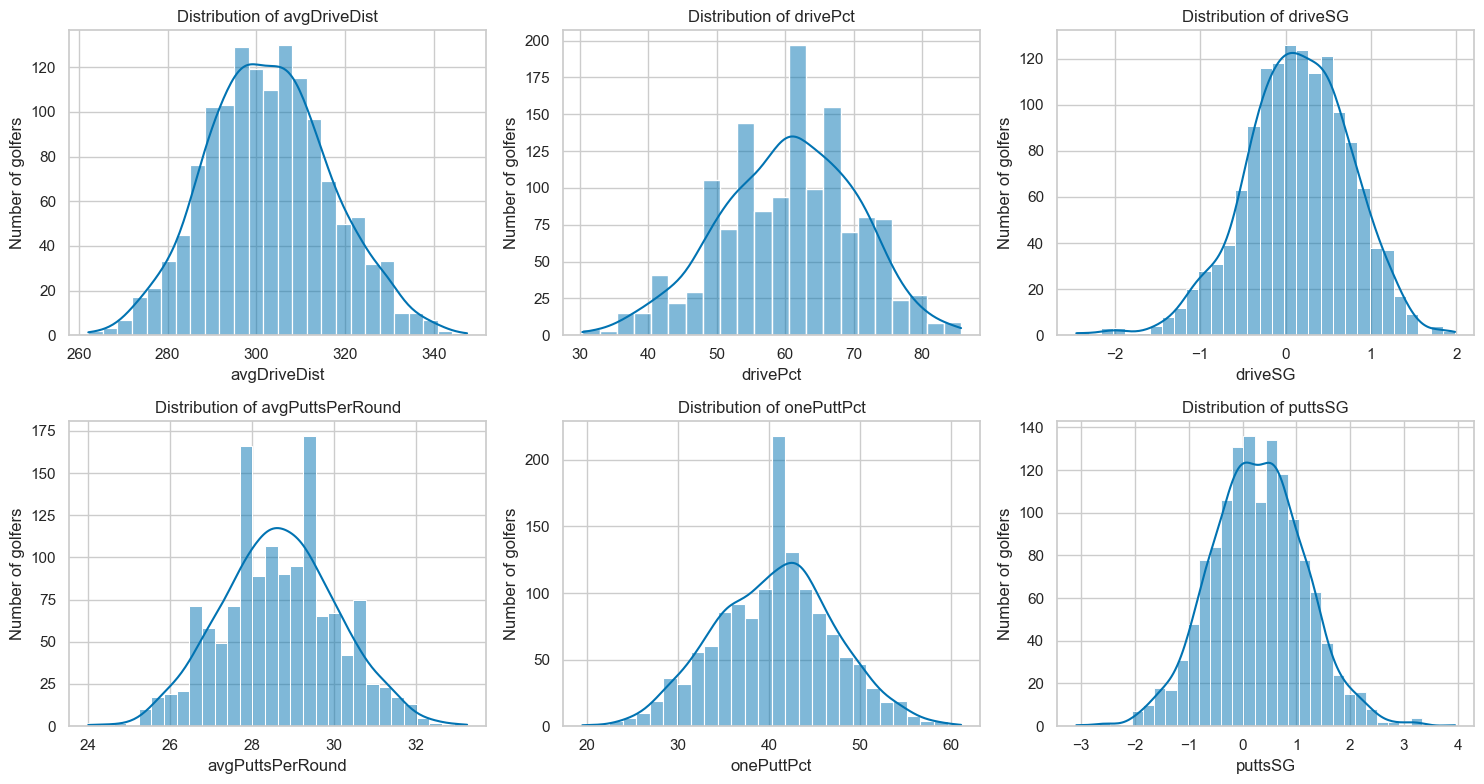

In [3]:
eda_features = [
    "avgDriveDist", "drivePct", "driveSG",
    "avgPuttsPerRound", "onePuttPct", "puttsSG"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, column in zip(axes.ravel(), eda_features):
    sns.histplot(df[column], kde=True, ax=ax)
    ax.set_title(f"Distribution of {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Number of golfers")

plt.tight_layout()
plt.show()


**Distribution analysis.** The feature distributions provide an initial view of scale, skewness and potentially extreme observations. This is used to determine whether robust preprocessing and scaling are appropriate for the modelling stage.

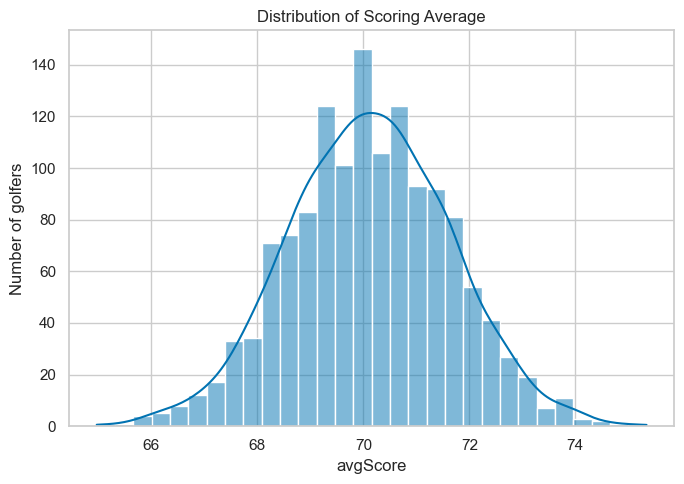

In [4]:
plt.figure(figsize=(7, 5))
sns.histplot(df["avgScore"], kde=True, bins=30)
plt.title("Distribution of Scoring Average")
plt.xlabel("avgScore")
plt.ylabel("Number of golfers")
plt.tight_layout()
plt.show()


**Target analysis.** The `avgScore` distribution shows the spread of scoring averages that the regression models must learn. A concentrated target range means relatively small prediction errors can be important when comparing golfers.

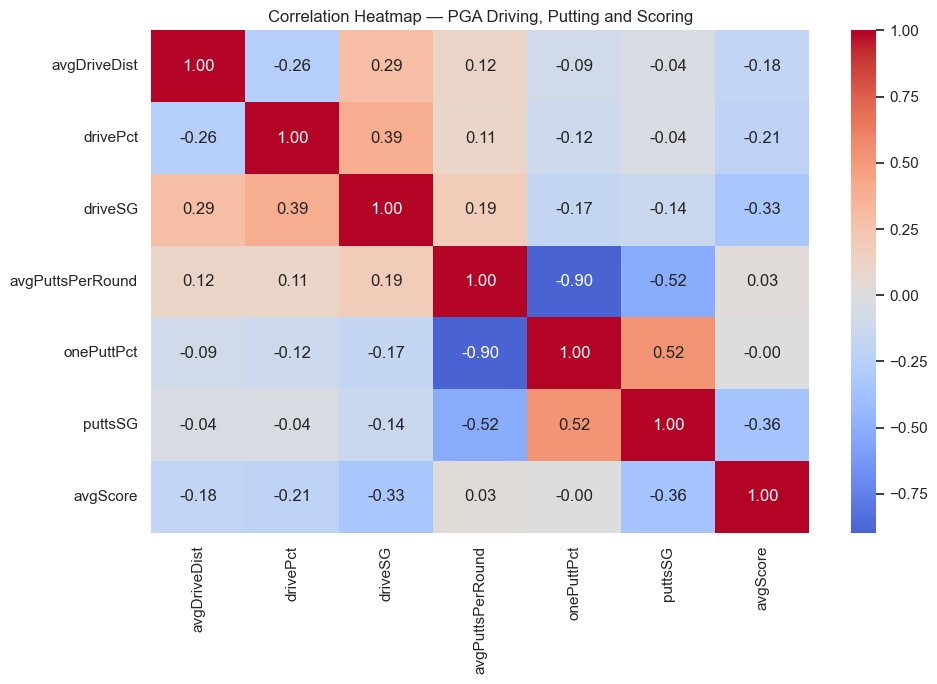

In [5]:
corr_cols = [
    "avgDriveDist", "drivePct", "driveSG",
    "avgPuttsPerRound", "onePuttPct", "puttsSG", "avgScore"
]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[corr_cols].corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Correlation Heatmap — PGA Driving, Putting and Scoring")
plt.tight_layout()
plt.show()


**Correlation analysis.** The correlation matrix provides a first indication of linear association with `avgScore` and highlights relationships among predictors. Predictor overlap is particularly relevant when interpreting and regularising linear models.

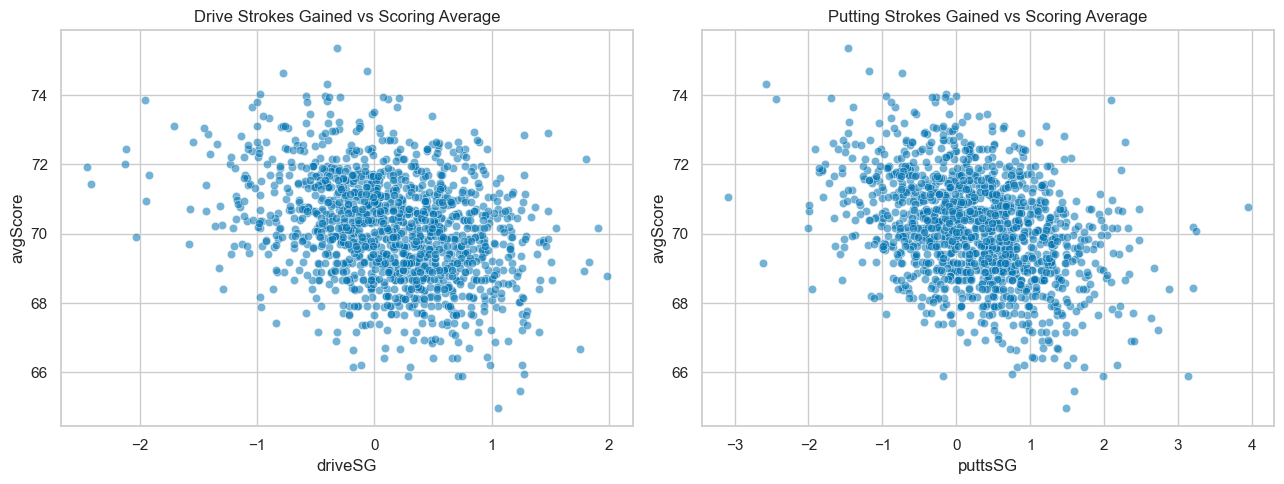

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=df, x="driveSG", y="avgScore",
    alpha=0.55, ax=axes[0]
)
axes[0].set_title("Drive Strokes Gained vs Scoring Average")
axes[0].set_xlabel("driveSG")
axes[0].set_ylabel("avgScore")

sns.scatterplot(
    data=df, x="puttsSG", y="avgScore",
    alpha=0.55, ax=axes[1]
)
axes[1].set_title("Putting Strokes Gained vs Scoring Average")
axes[1].set_xlabel("puttsSG")
axes[1].set_ylabel("avgScore")

plt.tight_layout()
plt.show()


**Feature-target relationships.** The scatter plots provide a visual check of the direction, strength and approximate form of the relationships between selected strokes-gained variables and scoring average. These relationships motivate the comparison of both linear and non-linear regressors.

## Section B — Preprocessing & Feature Engineering

### B1. Data cleaning

The goal here is not to remove every extreme value. A golfer with an unusually strong or weak statistic can still be a genuine observation. We check the data first and let the modelling pipeline handle missing numerical values.

In [7]:
model_columns = [
    "avgDriveDist", "drivePct", "driveSG",
    "avgPuttsPerRound", "onePuttPct", "puttsSG",
    "avgScore"
]

working_df = df[model_columns].copy()

print("Duplicate rows:", working_df.duplicated().sum())

outlier_summary = []

for column in model_columns:
    values = working_df[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((values < lower) | (values > upper)).sum()
    outlier_summary.append([column, count])

display(
    pd.DataFrame(outlier_summary, columns=["Feature", "IQR outlier count"])
)

print("\nMissing values:")
display(working_df.isna().sum().to_frame("missing_count"))


Duplicate rows: 10


,Feature,IQR outlier count
0,avgDriveDist,8
1,drivePct,2
2,driveSG,17
3,avgPuttsPerRound,14
4,onePuttPct,16
5,puttsSG,13
6,avgScore,10



Missing values:


,missing_count
avgDriveDist,11
drivePct,11
driveSG,11
avgPuttsPerRound,11
onePuttPct,11
puttsSG,11
avgScore,11


**Justification:** Missing numerical values will be imputed with the median inside the preprocessing pipeline. This keeps the imputation learned from the training data. Potential outliers are reported rather than deleted automatically, because the values represent real golfer performance.

### B2. Encoding, scaling and splitting

There are no categorical predictors in the final modelling set, so no one-hot encoding is needed. Scaling is included for models that depend on coefficient magnitude or distances.

For regression, a direct `stratify=y` split is not appropriate because `avgScore` is continuous. Instead, I create temporary quantile bins of the target so that the train and test sets have a similar spread of scoring averages. The bins are discarded before fitting the models.

In [8]:
# Feature engineering: combine strokes gained off the tee and putting.
working_df["totalSG"] = working_df["driveSG"] + working_df["puttsSG"]

feature_columns = [
    "avgDriveDist", "drivePct", "driveSG",
    "avgPuttsPerRound", "onePuttPct", "puttsSG",
    "totalSG"
]
target_column = "avgScore"

model_df = working_df[feature_columns + [target_column]].dropna(
    subset=[target_column]
).copy()

X = model_df[feature_columns]
y = model_df[target_column]

# Temporary bins only for a balanced regression split.
target_bins = pd.qcut(y, q=10, labels=False, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=target_bins
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (1100, 7)
X_test : (276, 7)
y_train: (1100,)
y_test : (276,)


**Feature engineering note:** `totalSG` adds `driveSG` and `puttsSG` to represent a golfer's combined strokes-gained contribution from the tee and on the greens. It is simple enough to explain in the viva and uses information already present in the dataset.

## Section C — Regression Track

All ten models below use the **same training data and the same held-out test set**. That is important because the comparison should reflect the algorithms, not different splits of the data.

In [9]:
numeric_features = feature_columns

scaled_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), numeric_features)
])

unscaled_preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median"))
    ]), numeric_features)
])

def scaled_pipeline(model):
    return Pipeline([
        ("preprocess", scaled_preprocessor),
        ("model", model)
    ])

def unscaled_pipeline(model):
    return Pipeline([
        ("preprocess", unscaled_preprocessor),
        ("model", model)
    ])

def regression_metrics(name, model, Xtr=X_train, ytr=y_train, Xte=X_test, yte=y_test):
    model.fit(Xtr, ytr)
    predictions = model.predict(Xte)
    return {
        "Model": name,
        "R2": r2_score(yte, predictions),
        "RMSE": np.sqrt(mean_squared_error(yte, predictions)),
        "MAE": mean_absolute_error(yte, predictions)
    }, predictions

results = []
predictions = {}
fitted_models = {}


## 1. Linear Regression

Linear Regression is the baseline. It assumes that the target can be represented as a weighted combination of the input variables. The coefficients are useful because they show the direction of the relationship after the features have been scaled.

In [10]:
linear_model = scaled_pipeline(LinearRegression())
metrics, pred = regression_metrics("Linear Regression", linear_model)
results.append(metrics)
predictions["Linear Regression"] = pred
fitted_models["Linear Regression"] = linear_model
pd.DataFrame([metrics])

,Model,R2,RMSE,MAE
0,Linear Regression,0.263096,1.288371,1.070311


## 2. Ridge Regression

Ridge is still a linear model, but it adds an L2 penalty to discourage very large coefficients. This is especially useful when predictors overlap in the information they contain. `alpha` controls the strength of the penalty.

In [11]:
ridge_pipeline = scaled_pipeline(Ridge())
ridge_grid = GridSearchCV(
    ridge_pipeline,
    {"model__alpha": [0.01, 0.1, 1, 10, 50, 100]},
    cv=5, scoring="r2", n_jobs=-1
)
ridge_grid.fit(X_train, y_train)
ridge_model = ridge_grid.best_estimator_
ridge_pred = ridge_model.predict(X_test)
ridge_metrics = {
    "Model": "Ridge Regression",
    "R2": r2_score(y_test, ridge_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, ridge_pred)),
    "MAE": mean_absolute_error(y_test, ridge_pred)
}
results.append(ridge_metrics)
predictions["Ridge Regression"] = ridge_pred
fitted_models["Ridge Regression"] = ridge_model
print("Best parameters:", ridge_grid.best_params_)
display(pd.DataFrame([ridge_metrics]))

Best parameters: {'model__alpha': 10}


,Model,R2,RMSE,MAE
0,Ridge Regression,0.262573,1.288828,1.071189


## 3. Lasso Regression

Lasso uses an L1 penalty. Apart from controlling coefficient size, L1 regularisation can push some coefficients exactly to zero, which makes the model useful for discussing feature sparsity.

In [12]:
lasso_pipeline = scaled_pipeline(Lasso(max_iter=20000))
lasso_grid = GridSearchCV(
    lasso_pipeline,
    {"model__alpha": [0.001, 0.01, 0.05, 0.1, 0.5, 1]},
    cv=5, scoring="r2", n_jobs=-1
)
lasso_grid.fit(X_train, y_train)
lasso_model = lasso_grid.best_estimator_
lasso_pred = lasso_model.predict(X_test)
lasso_metrics = {
    "Model": "Lasso Regression",
    "R2": r2_score(y_test, lasso_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, lasso_pred)),
    "MAE": mean_absolute_error(y_test, lasso_pred)
}
results.append(lasso_metrics)
predictions["Lasso Regression"] = lasso_pred
fitted_models["Lasso Regression"] = lasso_model
print("Best parameters:", lasso_grid.best_params_)
display(pd.DataFrame([lasso_metrics]))

Best parameters: {'model__alpha': 0.01}


,Model,R2,RMSE,MAE
0,Lasso Regression,0.257987,1.292829,1.076263


## 4. ElasticNet Regression

ElasticNet combines L1 and L2 regularisation. `alpha` controls the overall penalty and `l1_ratio` controls how much of that penalty behaves like Lasso versus Ridge.

In [13]:
elastic_model = scaled_pipeline(ElasticNet(max_iter=20000))
elastic_grid = GridSearchCV(
    elastic_model,
    {
        "model__alpha": [0.001, 0.01, 0.05, 0.1, 0.5],
        "model__l1_ratio": [0.2, 0.5, 0.8]
    },
    cv=5, scoring="r2", n_jobs=-1
)
elastic_grid.fit(X_train, y_train)
elastic_best = elastic_grid.best_estimator_
elastic_pred = elastic_best.predict(X_test)
elastic_metrics = {
    "Model": "ElasticNet Regression",
    "R2": r2_score(y_test, elastic_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, elastic_pred)),
    "MAE": mean_absolute_error(y_test, elastic_pred)
}
results.append(elastic_metrics)
predictions["ElasticNet Regression"] = elastic_pred
fitted_models["ElasticNet Regression"] = elastic_best
print("Best parameters:", elastic_grid.best_params_)
display(pd.DataFrame([elastic_metrics]))

Best parameters: {'model__alpha': 0.01, 'model__l1_ratio': 0.8}


,Model,R2,RMSE,MAE
0,ElasticNet Regression,0.259371,1.291623,1.074867


## 5. Polynomial Regression

Polynomial Regression is ordinary Linear Regression after adding polynomial terms. Degree 2 lets the model represent simple curves and pairwise interactions. I compare degrees rather than assuming that a more complicated polynomial is automatically better.

In [14]:
poly_pipeline = Pipeline([
    ("preprocess", ColumnTransformer([
        ("numeric", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("poly", PolynomialFeatures(include_bias=False)),
            ("scaler", StandardScaler())
        ]), numeric_features)
    ])),
    ("model", LinearRegression())
])
poly_grid = GridSearchCV(
    poly_pipeline,
    {"preprocess__numeric__poly__degree": [2, 3]},
    cv=5, scoring="r2", n_jobs=-1
)
poly_grid.fit(X_train, y_train)
poly_model = poly_grid.best_estimator_
poly_pred = poly_model.predict(X_test)
poly_metrics = {
    "Model": "Polynomial Regression",
    "R2": r2_score(y_test, poly_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, poly_pred)),
    "MAE": mean_absolute_error(y_test, poly_pred)
}
results.append(poly_metrics)
predictions["Polynomial Regression"] = poly_pred
fitted_models["Polynomial Regression"] = poly_model
print("Best parameters:", poly_grid.best_params_)
display(pd.DataFrame([poly_metrics]))

Best parameters: {'preprocess__numeric__poly__degree': 2}


,Model,R2,RMSE,MAE
0,Polynomial Regression,0.261701,1.289589,1.065251


## 6. Decision Tree Regressor

A Decision Tree repeatedly splits the feature space into smaller groups. It can capture non-linear relationships without scaling, but a very deep tree can memorise the training data.

In [15]:
tree_model = unscaled_pipeline(DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE))
tree_metrics, tree_pred = regression_metrics("Decision Tree Regressor", tree_model)
results.append(tree_metrics)
predictions["Decision Tree Regressor"] = tree_pred
fitted_models["Decision Tree Regressor"] = tree_model
display(pd.DataFrame([tree_metrics]))

,Model,R2,RMSE,MAE
0,Decision Tree Regressor,0.076811,1.442051,1.167006


## 7. Random Forest Regressor

Random Forest is an ensemble of Decision Trees. Each tree is trained on a different bootstrap sample and the final prediction is an average across the trees. The ensemble usually reduces the variance of one individual tree.

In [16]:
rf_pipeline = unscaled_pipeline(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)
)
rf_grid = GridSearchCV(
    rf_pipeline,
    {
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 5, 10]
    },
    cv=5, scoring="r2", n_jobs=-1
)
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_
rf_pred = rf_model.predict(X_test)
rf_metrics = {
    "Model": "Random Forest Regressor",
    "R2": r2_score(y_test, rf_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred)),
    "MAE": mean_absolute_error(y_test, rf_pred)
}
results.append(rf_metrics)
predictions["Random Forest Regressor"] = rf_pred
fitted_models["Random Forest Regressor"] = rf_model
print("Best parameters:", rf_grid.best_params_)
display(pd.DataFrame([rf_metrics]))

Best parameters: {'model__max_depth': 5, 'model__n_estimators': 100}


,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.20912,1.334722,1.112612


## 8. Gradient Boosting Regressor

Gradient Boosting also builds trees as an ensemble, but it does so sequentially. Each new tree focuses on reducing the errors left by the earlier trees. The learning rate controls how strongly each new tree contributes.

In [17]:
gbr_model = unscaled_pipeline(
    GradientBoostingRegressor(random_state=RANDOM_STATE)
)
gbr_grid = GridSearchCV(
    gbr_model,
    {
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [2, 3]
    },
    cv=5, scoring="r2", n_jobs=-1
)
gbr_grid.fit(X_train, y_train)
gbr_model_best = gbr_grid.best_estimator_
gbr_pred = gbr_model_best.predict(X_test)
gbr_metrics = {
    "Model": "Gradient Boosting Regressor",
    "R2": r2_score(y_test, gbr_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, gbr_pred)),
    "MAE": mean_absolute_error(y_test, gbr_pred)
}
results.append(gbr_metrics)
predictions["Gradient Boosting Regressor"] = gbr_pred
fitted_models["Gradient Boosting Regressor"] = gbr_model_best
print("Best parameters:", gbr_grid.best_params_)
display(pd.DataFrame([gbr_metrics]))

Best parameters: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 100}


,Model,R2,RMSE,MAE
0,Gradient Boosting Regressor,0.229021,1.317822,1.090777


## 9. Support Vector Regressor

SVR tries to fit a function inside an epsilon-tube around the observations. With an RBF kernel it can represent non-linear relationships. Scaling is important because the model uses distances in feature space.

In [18]:
svr_model = scaled_pipeline(SVR())
svr_grid = GridSearchCV(
    svr_model,
    {
        "model__C": [0.1, 1, 10, 100],
        "model__kernel": ["linear", "rbf"]
    },
    cv=5, scoring="r2", n_jobs=-1
)
svr_grid.fit(X_train, y_train)
svr_best = svr_grid.best_estimator_
svr_pred = svr_best.predict(X_test)
svr_metrics = {
    "Model": "Support Vector Regressor",
    "R2": r2_score(y_test, svr_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, svr_pred)),
    "MAE": mean_absolute_error(y_test, svr_pred)
}
results.append(svr_metrics)
predictions["Support Vector Regressor"] = svr_pred
fitted_models["Support Vector Regressor"] = svr_best
print("Best parameters:", svr_grid.best_params_)
display(pd.DataFrame([svr_metrics]))

Best parameters: {'model__C': 0.1, 'model__kernel': 'linear'}


,Model,R2,RMSE,MAE
0,Support Vector Regressor,0.26827,1.28384,1.064858


## 10. K-Nearest Neighbors Regressor

KNN does not learn a fixed equation. For a new observation it finds the closest training observations and averages their target values. Scaling matters because the prediction depends directly on distances.

In [19]:
knn_model = scaled_pipeline(KNeighborsRegressor())
knn_grid = GridSearchCV(
    knn_model,
    {
        "model__n_neighbors": [3, 5, 7, 11, 15, 21],
        "model__weights": ["uniform", "distance"],
        "model__metric": ["euclidean", "manhattan"]
    },
    cv=5, scoring="r2", n_jobs=-1
)
knn_grid.fit(X_train, y_train)
knn_best = knn_grid.best_estimator_
knn_pred = knn_best.predict(X_test)
knn_metrics = {
    "Model": "KNN Regressor",
    "R2": r2_score(y_test, knn_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, knn_pred)),
    "MAE": mean_absolute_error(y_test, knn_pred)
}
results.append(knn_metrics)
predictions["KNN Regressor"] = knn_pred
fitted_models["KNN Regressor"] = knn_best
print("Best parameters:", knn_grid.best_params_)
display(pd.DataFrame([knn_metrics]))

Best parameters: {'model__metric': 'euclidean', 'model__n_neighbors': 21, 'model__weights': 'uniform'}


,Model,R2,RMSE,MAE
0,KNN Regressor,0.239518,1.30882,1.073637


## Section K — Final Regression Comparison

This is the main table for the Review 1 regression requirement. Every model was evaluated on the same held-out test set.

In [20]:
results_df = (
    pd.DataFrame(results)
    .sort_values("R2", ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))


,Model,R2,RMSE,MAE
0,Support Vector Regressor,0.2683,1.2838,1.0649
1,Linear Regression,0.2631,1.2884,1.0703
2,Ridge Regression,0.2626,1.2888,1.0712
3,Polynomial Regression,0.2617,1.2896,1.0653
4,ElasticNet Regression,0.2594,1.2916,1.0749
5,Lasso Regression,0.2580,1.2928,1.0763
6,KNN Regressor,0.2395,1.3088,1.0736
7,Gradient Boosting Regressor,0.2290,1.3178,1.0908
8,Random Forest Regressor,0.2091,1.3347,1.1126
9,Decision Tree Regressor,0.0768,1.4421,1.1670


### Algorithm comparison — interpretation guide

- **Linear / Ridge / Lasso / ElasticNet:** linear models whose main differences come from regularisation.
- **Polynomial Regression:** extends a linear model with polynomial and interaction terms.
- **Decision Tree:** captures non-linear rules through recursive splits.
- **Random Forest:** averages many trees to reduce variance.
- **Gradient Boosting:** builds trees sequentially, with later trees correcting earlier errors.
- **SVR:** uses a margin-based objective and can model non-linear relationships with kernels.
- **KNN:** relies on local similarity and therefore depends strongly on feature scaling.

The comparison table and plots below provide the empirical evidence for the relative behaviour of these approaches on the PGA dataset.


### Separate model-comparison visualisation

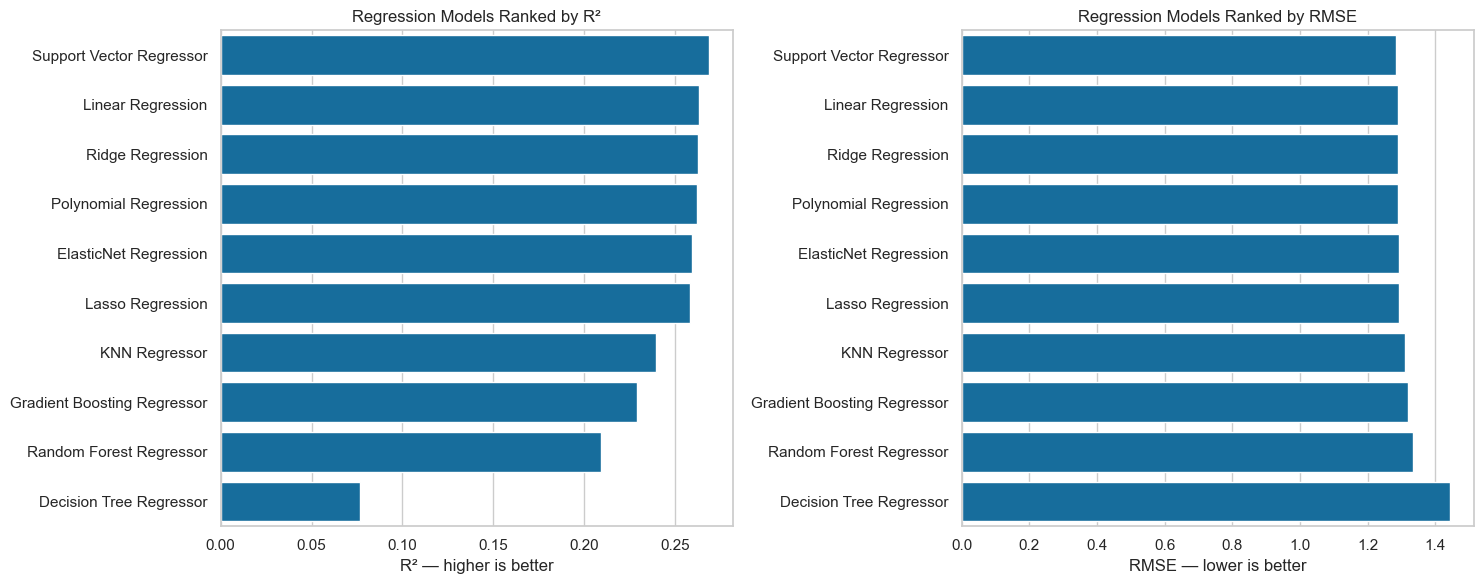

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=results_df, x="R2", y="Model", ax=axes[0])
axes[0].set_title("Regression Models Ranked by R²")
axes[0].set_xlabel("R² — higher is better")
axes[0].set_ylabel("")

sns.barplot(data=results_df, x="RMSE", y="Model", ax=axes[1])
axes[1].set_title("Regression Models Ranked by RMSE")
axes[1].set_xlabel("RMSE — lower is better")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


**Comparison interpretation.** The final table and paired comparison plot provide a common basis for evaluating the ten regressors. R² measures explained variance, while RMSE and MAE quantify prediction error on the same held-out test set.

## Section L — 5-Fold Cross-Validation for the Two Best Models

The course guideline requires cross-validation for the two best-performing models. Here the ranking is taken from the common test-set R² table, and then 5-fold CV is reported separately.

In [22]:
top_two = results_df.head(2)["Model"].tolist()

cv_rows = []

for model_name in top_two:
    scores = cross_val_score(
        fitted_models[model_name],
        X,
        y,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    cv_rows.append({
        "Model": model_name,
        "CV R2 mean": scores.mean(),
        "CV R2 std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_rows)
display(cv_results_df.round(4))


,Model,CV R2 mean,CV R2 std
0,Support Vector Regressor,0.1584,0.1174
1,Linear Regression,0.1516,0.1233


## Section M — Required Diagnostics for the Best Model

The rubric specifically asks for a residual plot, predicted-vs-actual plot and a feature-importance plot for at least one tree-based model.

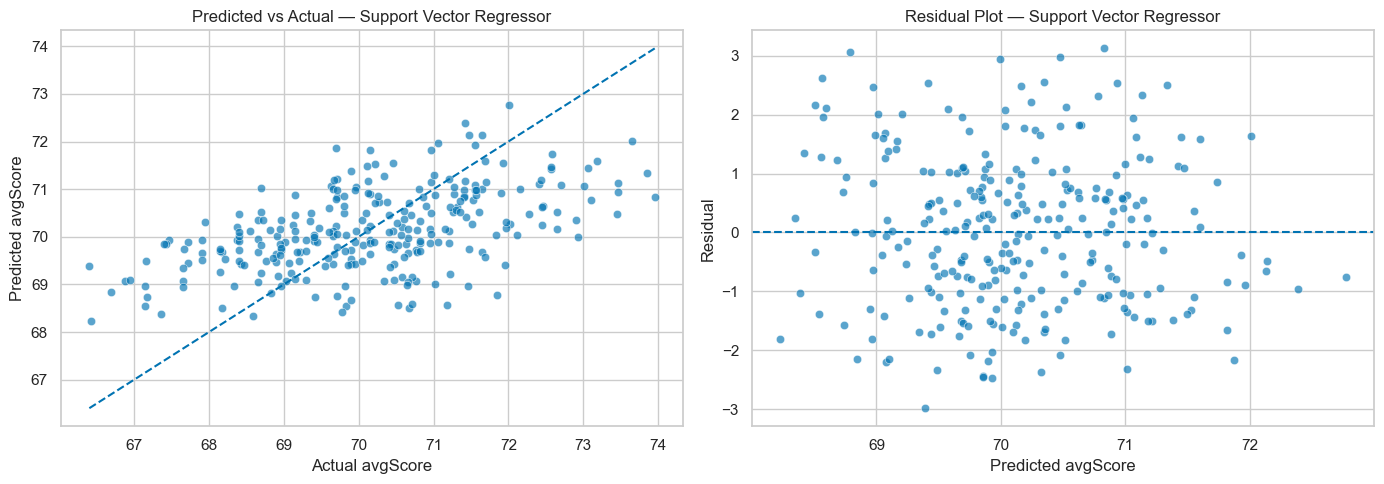

In [23]:
best_name = results_df.iloc[0]["Model"]
best_predictions = predictions[best_name]
residuals = y_test.to_numpy() - best_predictions

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=y_test,
    y=best_predictions,
    alpha=0.65,
    ax=axes[0]
)
lower = min(y_test.min(), best_predictions.min())
upper = max(y_test.max(), best_predictions.max())
axes[0].plot([lower, upper], [lower, upper], linestyle="--")
axes[0].set_title(f"Predicted vs Actual — {best_name}")
axes[0].set_xlabel("Actual avgScore")
axes[0].set_ylabel("Predicted avgScore")

sns.scatterplot(
    x=best_predictions,
    y=residuals,
    alpha=0.65,
    ax=axes[1]
)
axes[1].axhline(0, linestyle="--")
axes[1].set_title(f"Residual Plot — {best_name}")
axes[1].set_xlabel("Predicted avgScore")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()


**Diagnostic interpretation.** A strong predicted-vs-actual relationship places observations close to the reference diagonal. A useful residual plot should show errors distributed around zero without a clear systematic pattern.

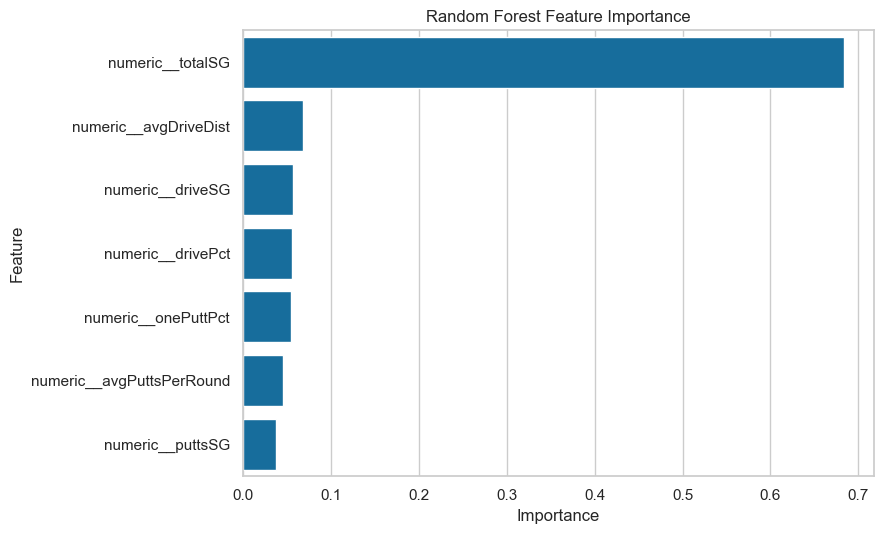

,Feature,Importance
6,numeric__totalSG,0.683577
0,numeric__avgDriveDist,0.067575
2,numeric__driveSG,0.056457
1,numeric__drivePct,0.055775
4,numeric__onePuttPct,0.054284
3,numeric__avgPuttsPerRound,0.045392
5,numeric__puttsSG,0.036940


In [24]:
# Tree-based feature importance — use the tuned Random Forest.
rf_preprocess = rf_model.named_steps["preprocess"]
rf_estimator = rf_model.named_steps["model"]

rf_feature_names = rf_preprocess.get_feature_names_out()
rf_importance = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_estimator.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(9, 5.5))
sns.barplot(data=rf_importance, x="Importance", y="Feature")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(rf_importance)


**Feature-importance interpretation.** Random Forest importance identifies variables that contributed strongly to the ensemble's predictive decisions. Importance indicates predictive usefulness within the fitted model and should not be interpreted as evidence of causation.